# Adhesion Decoupling Analysis

2-factor sweep decoupling NB-NB adhesion (J=50/40/20) and relative-rotation mode
(off / mu=0 / mu=45 / mu=90).  Division-rotation spread is fixed at sigma=50.
mudmut VCV=1, VOL-ABM and VOL-PDE, 50 runs per condition.

**Primary question:** does stronger NB-NB adhesion (lower J) maintain NB spatial
clustering as relative-rotation mode changes?

---
## Section 0 — Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
REPO_ROOT = Path.cwd()
while not (REPO_ROOT / 'pyproject.toml').exists():
    if REPO_ROOT.parent == REPO_ROOT:
        raise RuntimeError('Could not find repo root')
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT / 'src'))
from npa.sim_viz import render_raw, load_raw_snapshot_full

PROC_DIR    = REPO_ROOT / 'data/sim/processed_decoupling_adhesion'
FIGURES_DIR = PROC_DIR / 'figures/analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
run_idx = pd.read_csv(PROC_DIR / 'sim_run_index.csv', dtype=str)
run_idx['npz_row'] = run_idx['npz_row'].astype(int)

het_df  = pd.read_csv(PROC_DIR / 'het_contact_metrics.csv')
exp_df  = pd.read_csv(PROC_DIR / 'nb_exposure_metrics.csv')
coh_df  = pd.read_csv(PROC_DIR / 'nb_cohesion_metrics.csv')
conn_df = pd.read_csv(PROC_DIR / 'nb_connectivity_metrics.csv')

_BOOL_MAP = {'True': True, 'False': False, True: True, False: False}
for df in [het_df, exp_df, coh_df, conn_df]:
    df['adhesion']  = df['adhesion'].astype(int)
    df['div_stdev'] = df['div_stdev'].astype(int)
    df['relrot']    = df['relrot'].map(_BOOL_MAP)
conn_df['nb_connected'] = conn_df['nb_connected'].map(_BOOL_MAP)

print('Rows per CSV:', len(het_df))
print('Adhesion levels:', sorted(het_df['adhesion'].unique()))
print('Div stdev levels:', sorted(het_df['div_stdev'].unique()))
print('Sim IDs:', sorted(het_df['sim_id'].unique()))
print('Relrot:', het_df['relrot'].value_counts().to_dict())
print('Relrot mean levels:', sorted(het_df['relrot_mean'].dropna().unique()))

Rows per CSV: 1200
Adhesion levels: [np.int64(20), np.int64(40), np.int64(50)]
Div stdev levels: [np.int64(50)]
Sim IDs: ['vcv1_vol_abm', 'vcv1_vol_pde']
Relrot: {True: 900, False: 300}
Relrot mean levels: [np.float64(0.0), np.float64(45.0), np.float64(90.0)]


In [4]:
_base_cols = ['condition', 'sim_id', 'run_id']
_meta_cols = ['adhesion', 'div_stdev', 'relrot', 'relrot_mean',
              'critical_volume_mode', 'regulatory_dynamic']

all_df = (
    het_df[_base_cols + _meta_cols + ['norm_het_frac']]
    .merge(exp_df[_base_cols + ['exposed_frac']], on=_base_cols, how='left')
    .merge(coh_df[_base_cols + ['nb_cohesion_frac']], on=_base_cols, how='left')
    .merge(conn_df[_base_cols + ['nb_connected', 'nb_n_pixels']], on=_base_cols, how='left')
)

def _relrot_label(row) -> str:
    if not row['relrot']:
        return 'off'
    m = row['relrot_mean']
    return f'mu={int(m)}' if not pd.isna(m) else 'mu=?'

all_df['relrot_label'] = all_df.apply(_relrot_label, axis=1)

print('Combined df shape:', all_df.shape)
print('Relrot labels:', sorted(all_df['relrot_label'].unique()))

Combined df shape: (1200, 15)
Relrot labels: ['mu=0', 'mu=45', 'mu=90', 'off']


In [5]:
ADH_ORDER    = [50, 40, 20]
ADH_COLORS   = {50: '#aaaaaa', 40: '#6080c0', 20: '#c04060'}
ADH_LABELS   = {50: 'J=50\n(no diff.)', 40: 'J=40\n(baseline)', 20: 'J=20\n(strong)'}
RELROT_ORDER = ['off', 'mu=0', 'mu=45', 'mu=90']
RELROT_COLORS = {
    'off':   '#888888',
    'mu=0':  '#4e9ed4',
    'mu=45': '#e87b39',
    'mu=90': '#7b39e8',
}
REG_DYN_ORDER = ['VOL-ABM', 'VOL-PDE']

SPATIAL_METRICS = ['norm_het_frac', 'exposed_frac', 'nb_cohesion_frac']
SPATIAL_LABELS  = {
    'norm_het_frac':    'norm_het_frac',
    'exposed_frac':     'NB exposed frac.',
    'nb_cohesion_frac': 'NB cohesion frac.',
}

# Condition order for overview plots: adhesion → relrot
_cond_order = (
    all_df[['condition', 'adhesion', 'relrot_label']]
    .drop_duplicates()
    .sort_values(['adhesion', 'relrot_label'])
    ['condition'].tolist()
)
print(f'{len(_cond_order)} unique conditions')

12 unique conditions


In [6]:
from matplotlib.gridspec import GridSpec


def _cond_name(adh, relrot_label):
    base = f'mudmut_adh{adh}_divMean0Stdev50'
    if relrot_label == 'off':
        return base
    mu = int(relrot_label.split('=')[1])
    return f'{base}_relrotMean{mu}'


def _render_median_run(cond, sim_id, metric_df, metric_col, ax):
    sub = metric_df[(metric_df['condition'] == cond) & (metric_df['sim_id'] == sim_id)]
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                transform=ax.transAxes, fontsize=8)
        ax.axis('off')
        return np.nan
    med      = sub[metric_col].median()
    best_run = int(sub.loc[(sub[metric_col] - med).abs().idxmin(), 'run_id'])
    run_str  = str(best_run).zfill(4)
    match = run_idx[
        (run_idx['condition'] == cond) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_str)
    ]
    if match.empty:
        ax.text(0.5, 0.5, f'run {run_str}\nnot found', ha='center', va='center',
                transform=ax.transAxes, fontsize=7)
        ax.axis('off')
        return np.nan
    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r['cells_path'],
        REPO_ROOT / r['locs_path'],
    )
    render_raw(geo_raw, label_map=lmap, ax=ax, title='')
    ax.axis('off')
    return med

---
## Section 1 — Metric Overview

Distribution of spatial metrics across all 12 conditions × 50 runs per sim type.
Conditions sorted by adhesion level → relrot mode.
Box colour = adhesion level.

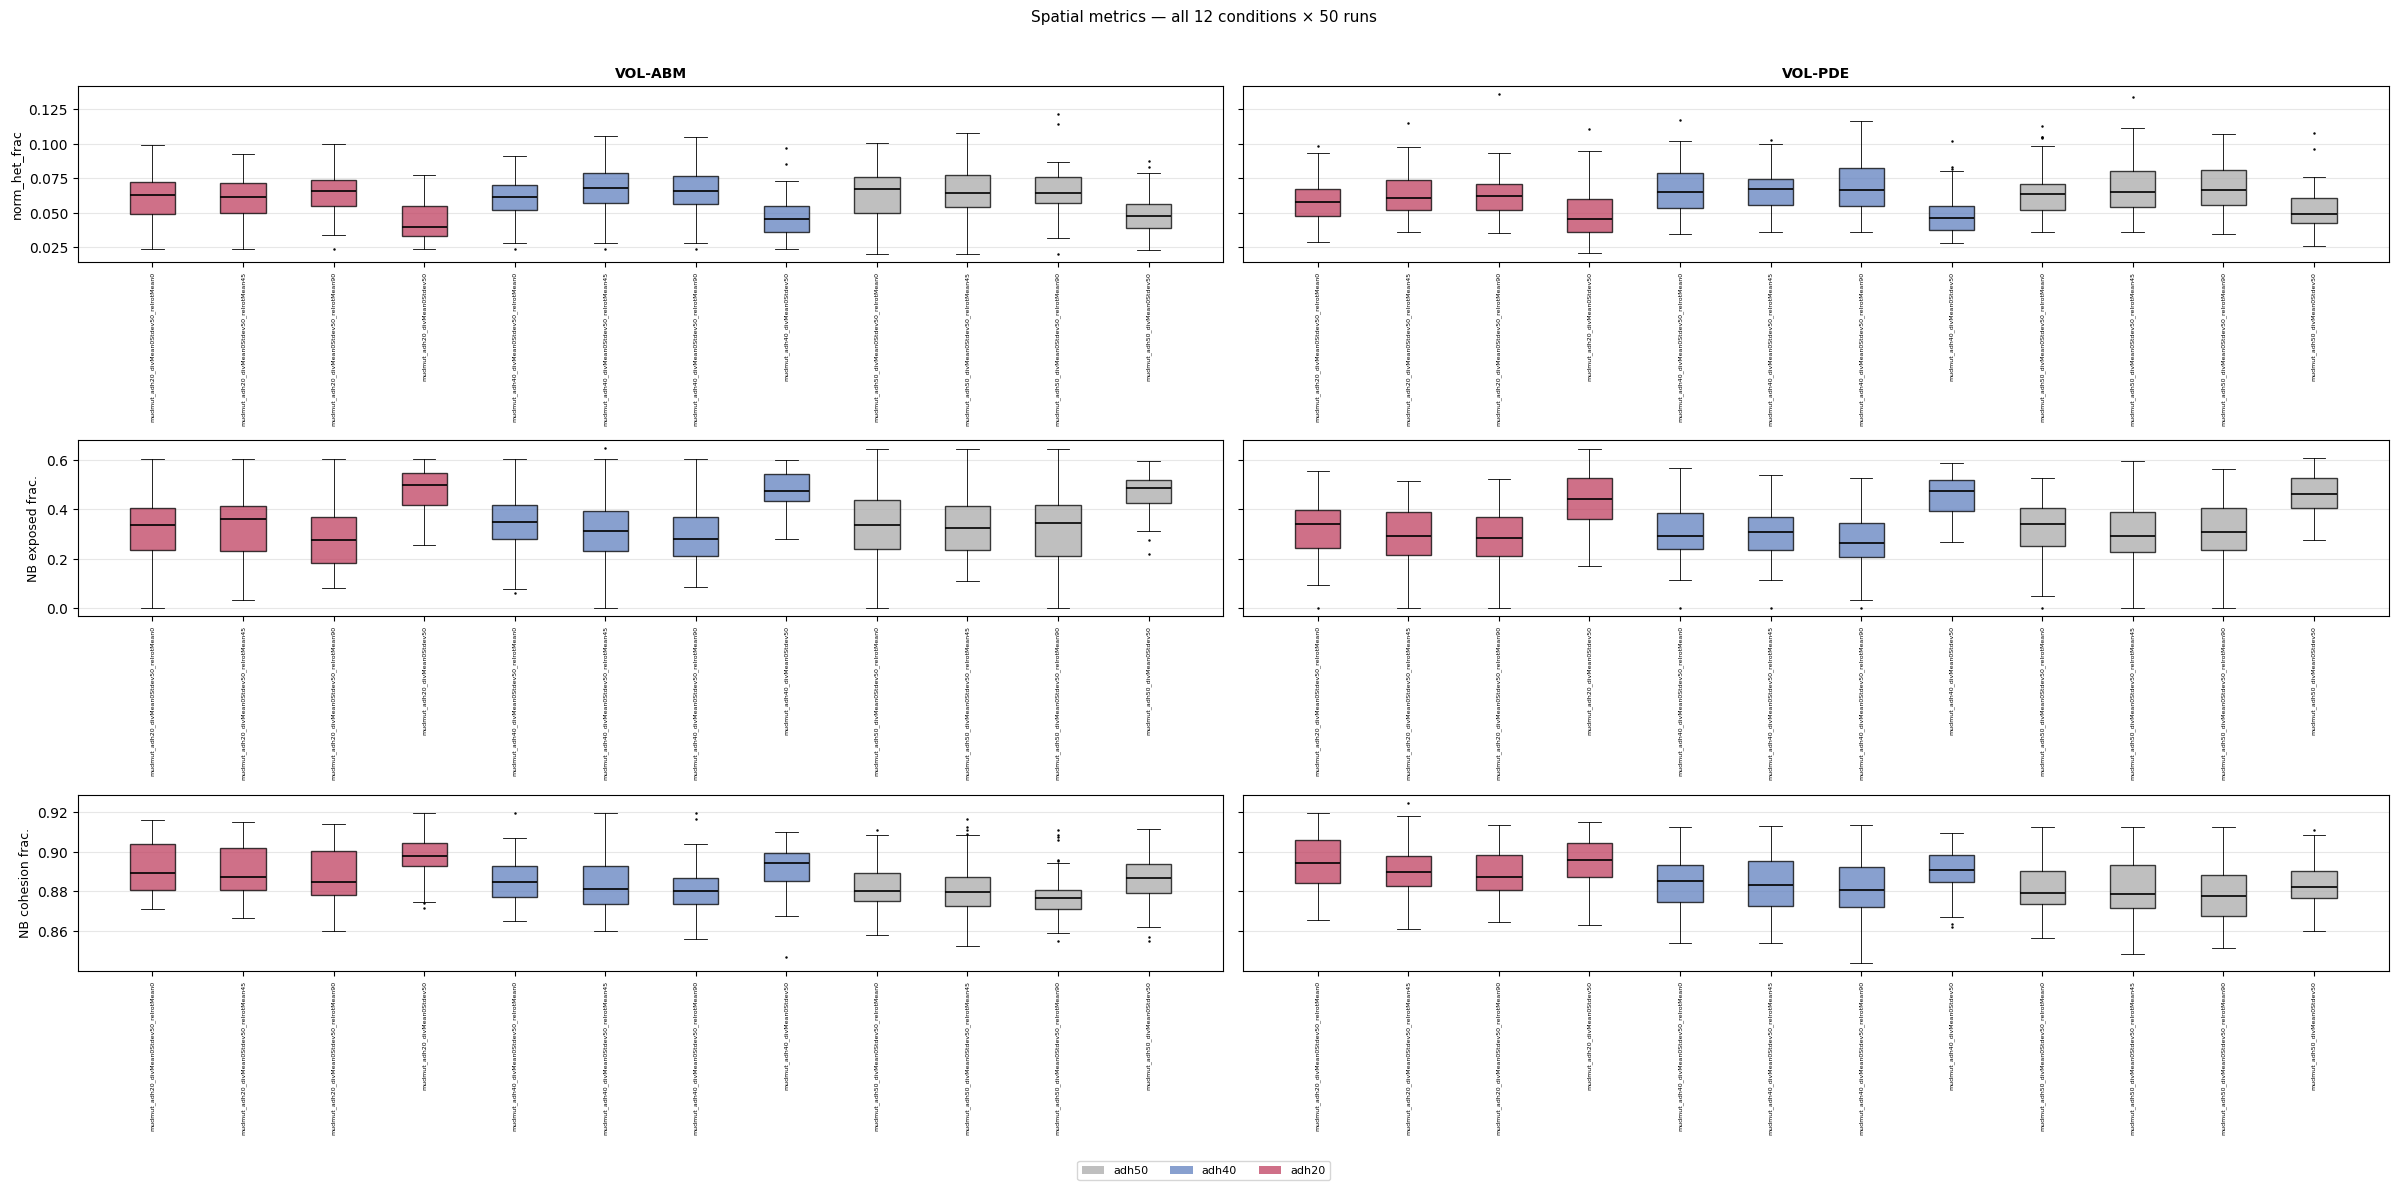

In [7]:
fig, axes = plt.subplots(
    len(SPATIAL_METRICS), len(REG_DYN_ORDER),
    figsize=(24, 4 * len(SPATIAL_METRICS)), sharey='row', squeeze=False,
)

for ri, metric in enumerate(SPATIAL_METRICS):
    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        ax = axes[ri, ci]
        sub = all_df[all_df['regulatory_dynamic'] == reg_dyn]

        _cond_adh = {
            c: int(sub[sub['condition'] == c]['adhesion'].iloc[0])
            for c in _cond_order if not sub[sub['condition'] == c].empty
        }
        data_list = [sub[sub['condition'] == c][metric].dropna().values for c in _cond_order]
        colors    = [ADH_COLORS.get(_cond_adh.get(c, 50), '#aaaaaa') for c in _cond_order]

        bp = ax.boxplot(
            data_list, positions=range(len(_cond_order)), widths=0.5,
            patch_artist=True,
            medianprops={'color': 'black', 'linewidth': 1.2},
            whiskerprops={'linewidth': 0.6},
            capprops={'linewidth': 0.6},
            flierprops={'marker': '.', 'markersize': 1.5, 'linestyle': 'none'},
            manage_ticks=False,
        )
        for box, c in zip(bp['boxes'], colors):
            box.set_facecolor(c)
            box.set_alpha(0.75)

        ax.set_xticks(range(len(_cond_order)))
        ax.set_xticklabels(_cond_order, rotation=90, ha='center', fontsize=4.5)
        ax.grid(axis='y', alpha=0.3)
        if ri == 0:
            ax.set_title(reg_dyn, fontsize=10, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(SPATIAL_LABELS[metric], fontsize=9)

legend_handles = [Patch(facecolor=ADH_COLORS[a], alpha=0.75, label=f'adh{a}')
                  for a in ADH_ORDER]
fig.suptitle('Spatial metrics — all 12 conditions × 50 runs', fontsize=11)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(FIGURES_DIR / 'overview_all_conditions.png', dpi=120, bbox_inches='tight')
plt.show()

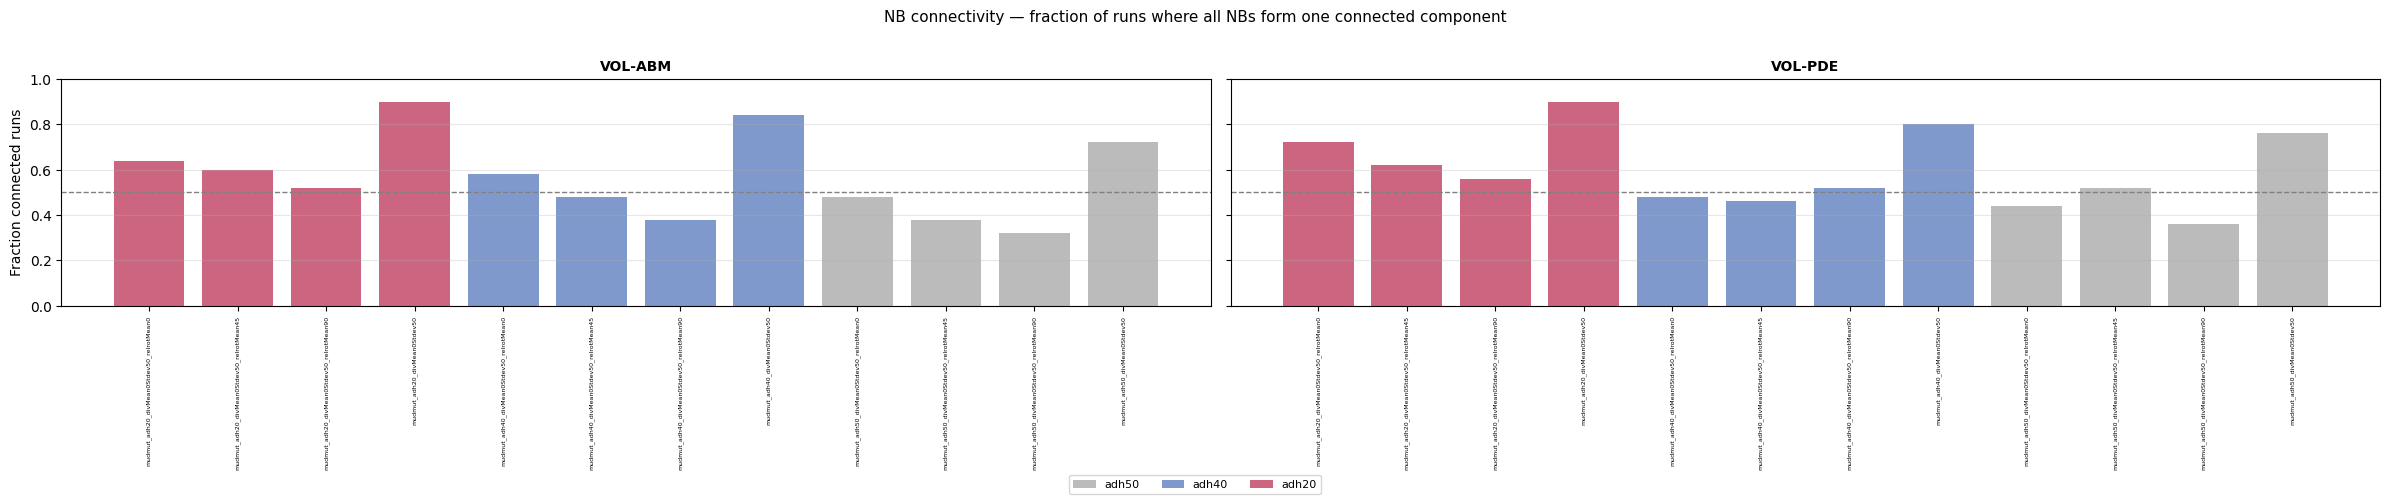

In [8]:
# NB connectivity: bar chart showing fraction of runs where all NBs are connected
conn_summary = (
    all_df
    .groupby(['condition', 'adhesion', 'regulatory_dynamic'])
    ['nb_connected'].mean()
    .reset_index(name='frac_connected')
)

fig, axes = plt.subplots(1, 2, figsize=(24, 5), sharey=True)
for ci, reg_dyn in enumerate(REG_DYN_ORDER):
    ax = axes[ci]
    sub = conn_summary[conn_summary['regulatory_dynamic'] == reg_dyn]

    _adh_for_cond = dict(zip(sub['condition'], sub['adhesion'].astype(int)))
    heights = []
    colors  = []
    for c in _cond_order:
        row = sub[sub['condition'] == c]
        heights.append(float(row['frac_connected'].iloc[0]) if not row.empty else 0.0)
        colors.append(ADH_COLORS.get(_adh_for_cond.get(c, 50), '#aaaaaa'))

    ax.bar(range(len(_cond_order)), heights, color=colors, alpha=0.8, edgecolor='none')
    ax.set_xticks(range(len(_cond_order)))
    ax.set_xticklabels(_cond_order, rotation=90, ha='center', fontsize=4.5)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(reg_dyn, fontsize=10, fontweight='bold')
    if ci == 0:
        ax.set_ylabel('Fraction connected runs')

legend_handles = [Patch(facecolor=ADH_COLORS[a], alpha=0.8, label=f'adh{a}')
                  for a in ADH_ORDER]
fig.suptitle(
    'NB connectivity — fraction of runs where all NBs form one connected component',
    fontsize=11,
)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(FIGURES_DIR / 'overview_connectivity.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 2 — Adhesion Main Effect

At baseline (relrot=off): how does reducing J(NB,NB) from 50 → 40 → 20
change spatial clustering?

**Expected:** lower J → higher cohesion fraction, higher connectivity rate,
lower norm_het_frac.

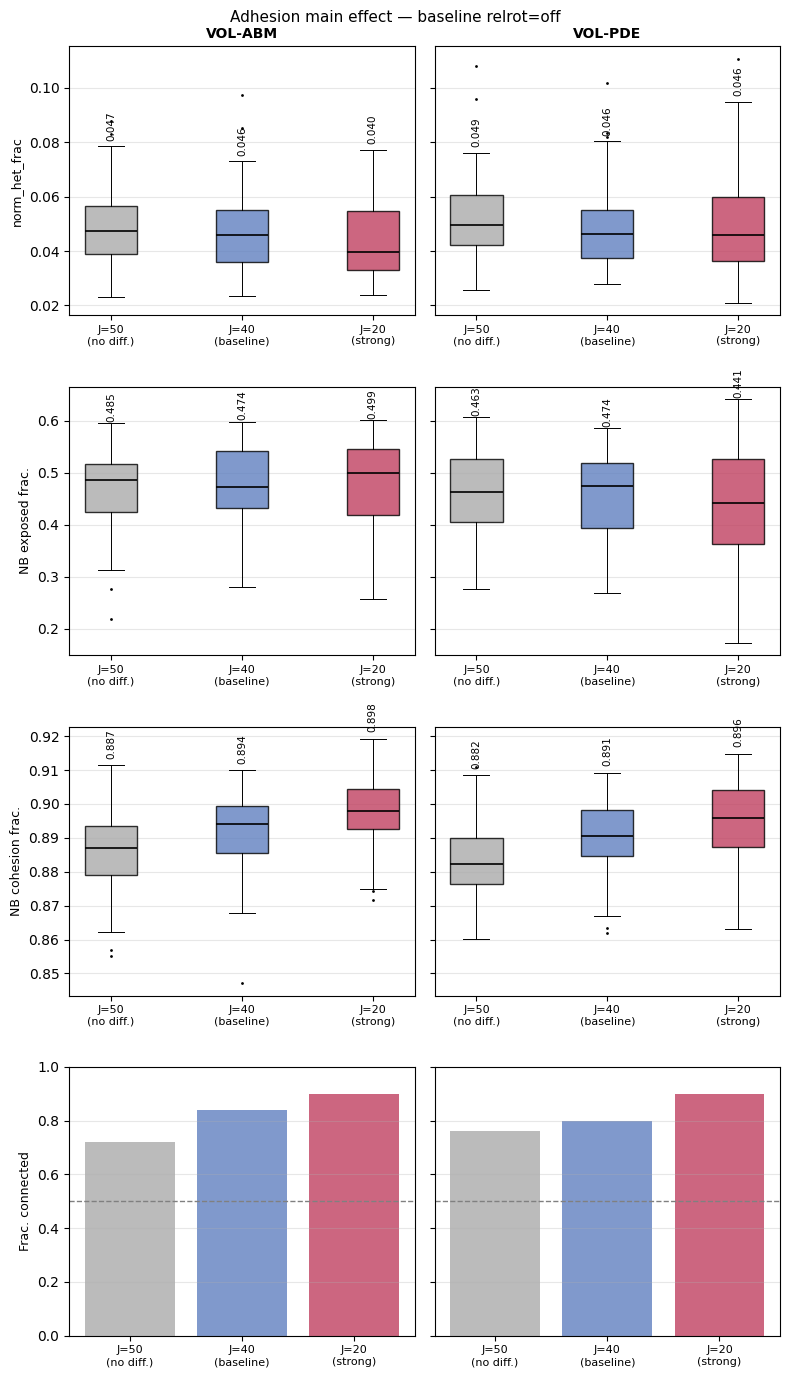

In [9]:
_baseline = all_df[all_df['relrot_label'] == 'off']

_plot_metrics_2 = SPATIAL_METRICS + ['nb_connected']
_metric_ylabels = {**SPATIAL_LABELS, 'nb_connected': 'Frac. connected'}

fig, axes = plt.subplots(
    len(_plot_metrics_2), len(REG_DYN_ORDER),
    figsize=(8, 3.5 * len(_plot_metrics_2)), sharey='row', squeeze=False,
)

for ri, metric in enumerate(_plot_metrics_2):
    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        ax = axes[ri, ci]
        sub = _baseline[_baseline['regulatory_dynamic'] == reg_dyn]

        if metric == 'nb_connected':
            fracs = [sub[sub['adhesion'] == adh]['nb_connected'].mean() for adh in ADH_ORDER]
            ax.bar(range(len(ADH_ORDER)), fracs,
                   color=[ADH_COLORS[a] for a in ADH_ORDER], alpha=0.8)
            ax.set_ylim(0, 1)
            ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
        else:
            for ti, adh in enumerate(ADH_ORDER):
                runs = sub[sub['adhesion'] == adh][metric].dropna()
                if runs.empty:
                    continue
                bp = ax.boxplot(
                    [runs], positions=[ti], widths=0.4,
                    patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 1.2},
                    whiskerprops={'linewidth': 0.7},
                    capprops={'linewidth': 0.7},
                    flierprops={'marker': '.', 'markersize': 2, 'linestyle': 'none'},
                    manage_ticks=False,
                )
                bp['boxes'][0].set_facecolor(ADH_COLORS[adh])
                bp['boxes'][0].set_alpha(0.8)
                med = float(np.median(runs))
                ax.text(ti, bp['caps'][1].get_ydata()[0] + 0.002,
                        f'{med:.3f}', ha='center', va='bottom', fontsize=7.5, rotation=90)

        ax.set_xticks(range(len(ADH_ORDER)))
        ax.set_xticklabels([ADH_LABELS[a] for a in ADH_ORDER], fontsize=8)
        ax.grid(axis='y', alpha=0.3)
        if ri == 0:
            ax.set_title(reg_dyn, fontsize=10, fontweight='bold')
        if ci == 0:
            ax.set_ylabel(_metric_ylabels.get(metric, metric), fontsize=9)

fig.suptitle('Adhesion main effect — baseline relrot=off', fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'adhesion_main_effect.png', dpi=120, bbox_inches='tight')
plt.show()

### Section 2b — Adhesion Main Effect: Example Lineages

One lineage per adhesion level at baseline (relrot=off), VOL-ABM.
Run selected at median NB exposed fraction.

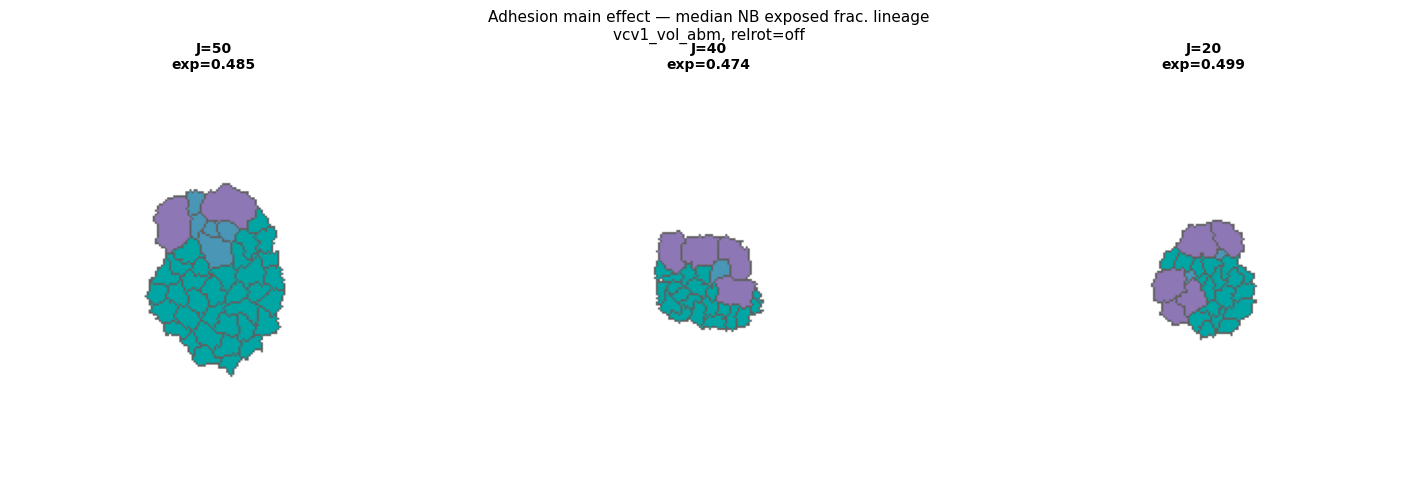

In [10]:
_SIM_ID = 'vcv1_vol_abm'

fig, axes = plt.subplots(1, len(ADH_ORDER), figsize=(5 * len(ADH_ORDER), 5), squeeze=False)

for ci, adh in enumerate(ADH_ORDER):
    ax      = axes[0, ci]
    cond    = _cond_name(adh, 'off')
    med_val = _render_median_run(cond, _SIM_ID, exp_df, 'exposed_frac', ax)

    title_lines = [f'J={adh}']
    if not np.isnan(med_val):
        title_lines.append(f'exp={med_val:.3f}')
    ax.set_title('\n'.join(title_lines), fontsize=10, fontweight='bold')

fig.suptitle(
    f'Adhesion main effect — median NB exposed frac. lineage\n'
    f'{_SIM_ID}, relrot=off',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'adhesion_main_effect_example_lineages.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 3 — Relative Rotation Sweep

How does enabling relative rotation (and varying its mean) interact
with adhesion strength?

Relative rotation `mu=0` means daughters divide symmetrically around the apical axis
(same as off, but with the relative-rotation mechanism active). `mu=90` sends daughters
perpendicular to the apical axis.

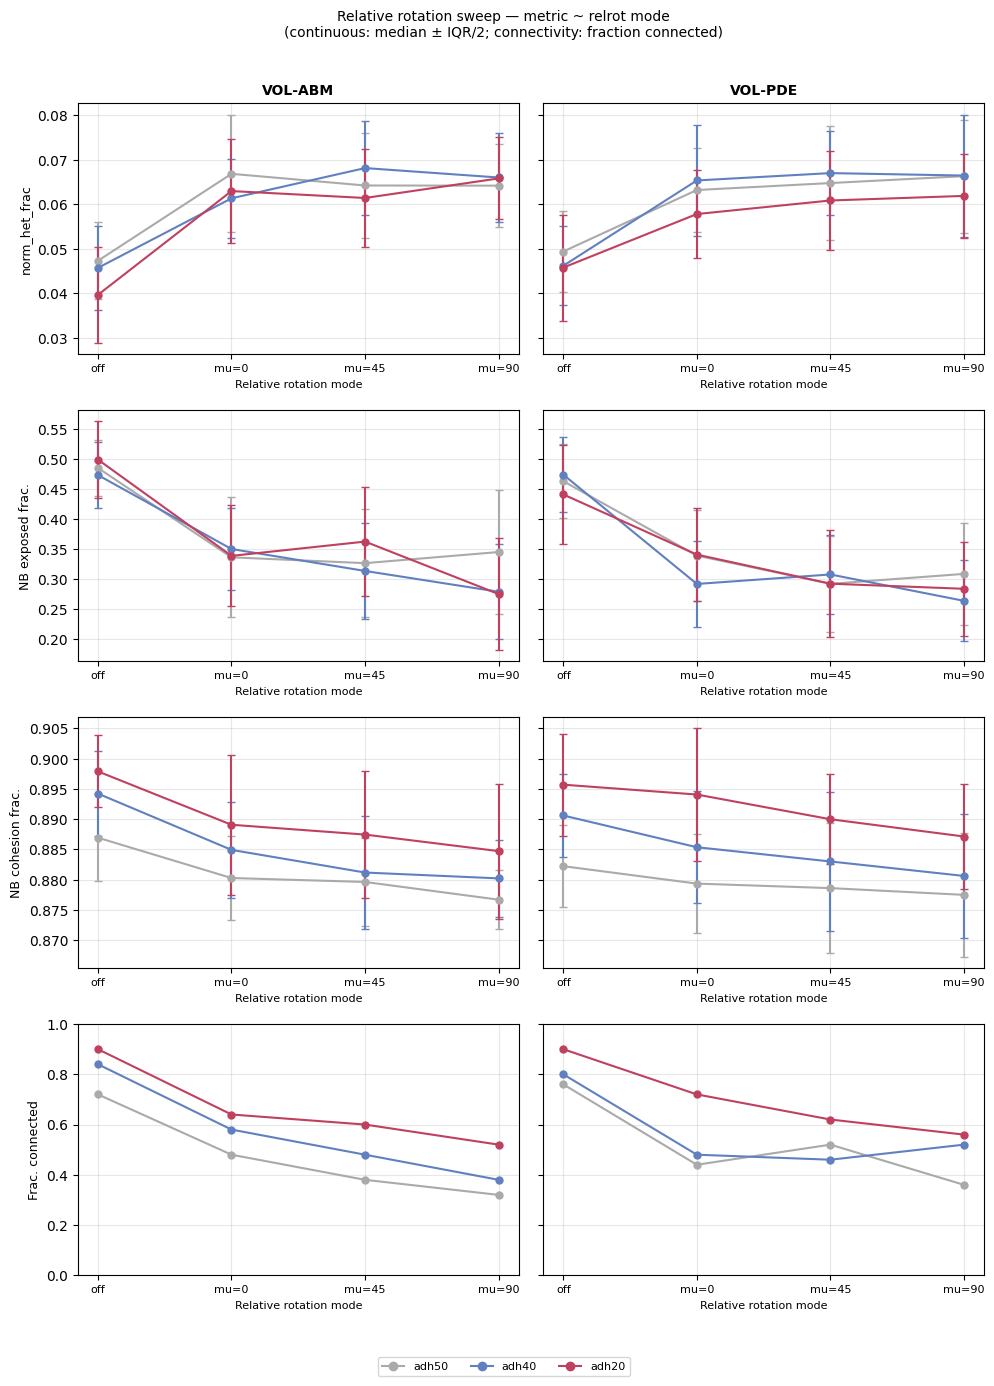

In [11]:
_relrot_slice = all_df
_plot_metrics_4 = SPATIAL_METRICS + ['nb_connected']

fig, axes = plt.subplots(
    len(_plot_metrics_4), len(REG_DYN_ORDER),
    figsize=(10, 3.5 * len(_plot_metrics_4)), sharey='row', squeeze=False,
)

for ri, metric in enumerate(_plot_metrics_4):
    for ci, reg_dyn in enumerate(REG_DYN_ORDER):
        ax = axes[ri, ci]
        sub = _relrot_slice[_relrot_slice['regulatory_dynamic'] == reg_dyn]

        for adh in ADH_ORDER:
            ys = []
            for rl in RELROT_ORDER:
                vals = sub[(sub['adhesion'] == adh) & (sub['relrot_label'] == rl)][metric].dropna()
                if vals.empty:
                    ys.append(np.nan)
                    continue
                if metric == 'nb_connected':
                    ys.append(float(vals.mean()))
                else:
                    ys.append(float(vals.median()))

            if metric == 'nb_connected':
                ax.plot(range(len(RELROT_ORDER)), ys, color=ADH_COLORS[adh], marker='o',
                        linewidth=1.5, markersize=5, label=f'adh{adh}')
            else:
                errs = []
                for rl in RELROT_ORDER:
                    vals = sub[(sub['adhesion'] == adh) & (sub['relrot_label'] == rl)][metric].dropna()
                    errs.append((float(vals.quantile(0.75)) - float(vals.quantile(0.25))) / 2
                                if not vals.empty else 0.0)
                ax.errorbar(range(len(RELROT_ORDER)), ys, yerr=errs,
                            color=ADH_COLORS[adh], marker='o', linewidth=1.5,
                            markersize=5, capsize=3, label=f'adh{adh}')

        ax.set_xticks(range(len(RELROT_ORDER)))
        ax.set_xticklabels(RELROT_ORDER, fontsize=8)
        ax.set_xlabel('Relative rotation mode', fontsize=8)
        ax.grid(alpha=0.3)
        if metric == 'nb_connected':
            ax.set_ylim(0, 1)
        if ri == 0:
            ax.set_title(reg_dyn, fontsize=10, fontweight='bold')
        if ci == 0:
            ylabel = SPATIAL_LABELS.get(metric, 'Frac. connected')
            ax.set_ylabel(ylabel, fontsize=9)

legend_handles = [
    Line2D([0], [0], color=ADH_COLORS[a], marker='o', label=f'adh{a}')
    for a in ADH_ORDER
]
fig.suptitle(
    'Relative rotation sweep — metric ~ relrot mode\n'
    '(continuous: median ± IQR/2; connectivity: fraction connected)',
    fontsize=10,
)
fig.legend(handles=legend_handles, fontsize=8, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, 0.0))
fig.tight_layout(rect=[0, 0.04, 1, 0.97])
fig.savefig(FIGURES_DIR / 'relrot_sweep.png', dpi=120, bbox_inches='tight')
plt.show()

### Section 3b — Relative Rotation Sweep: Example Lineages

One representative end-state per (adhesion × relrot mode) cell, VOL-ABM.
Each image is the run closest to the median `exposed_frac` for that condition.
Row = adhesion level; column = relative rotation mode.

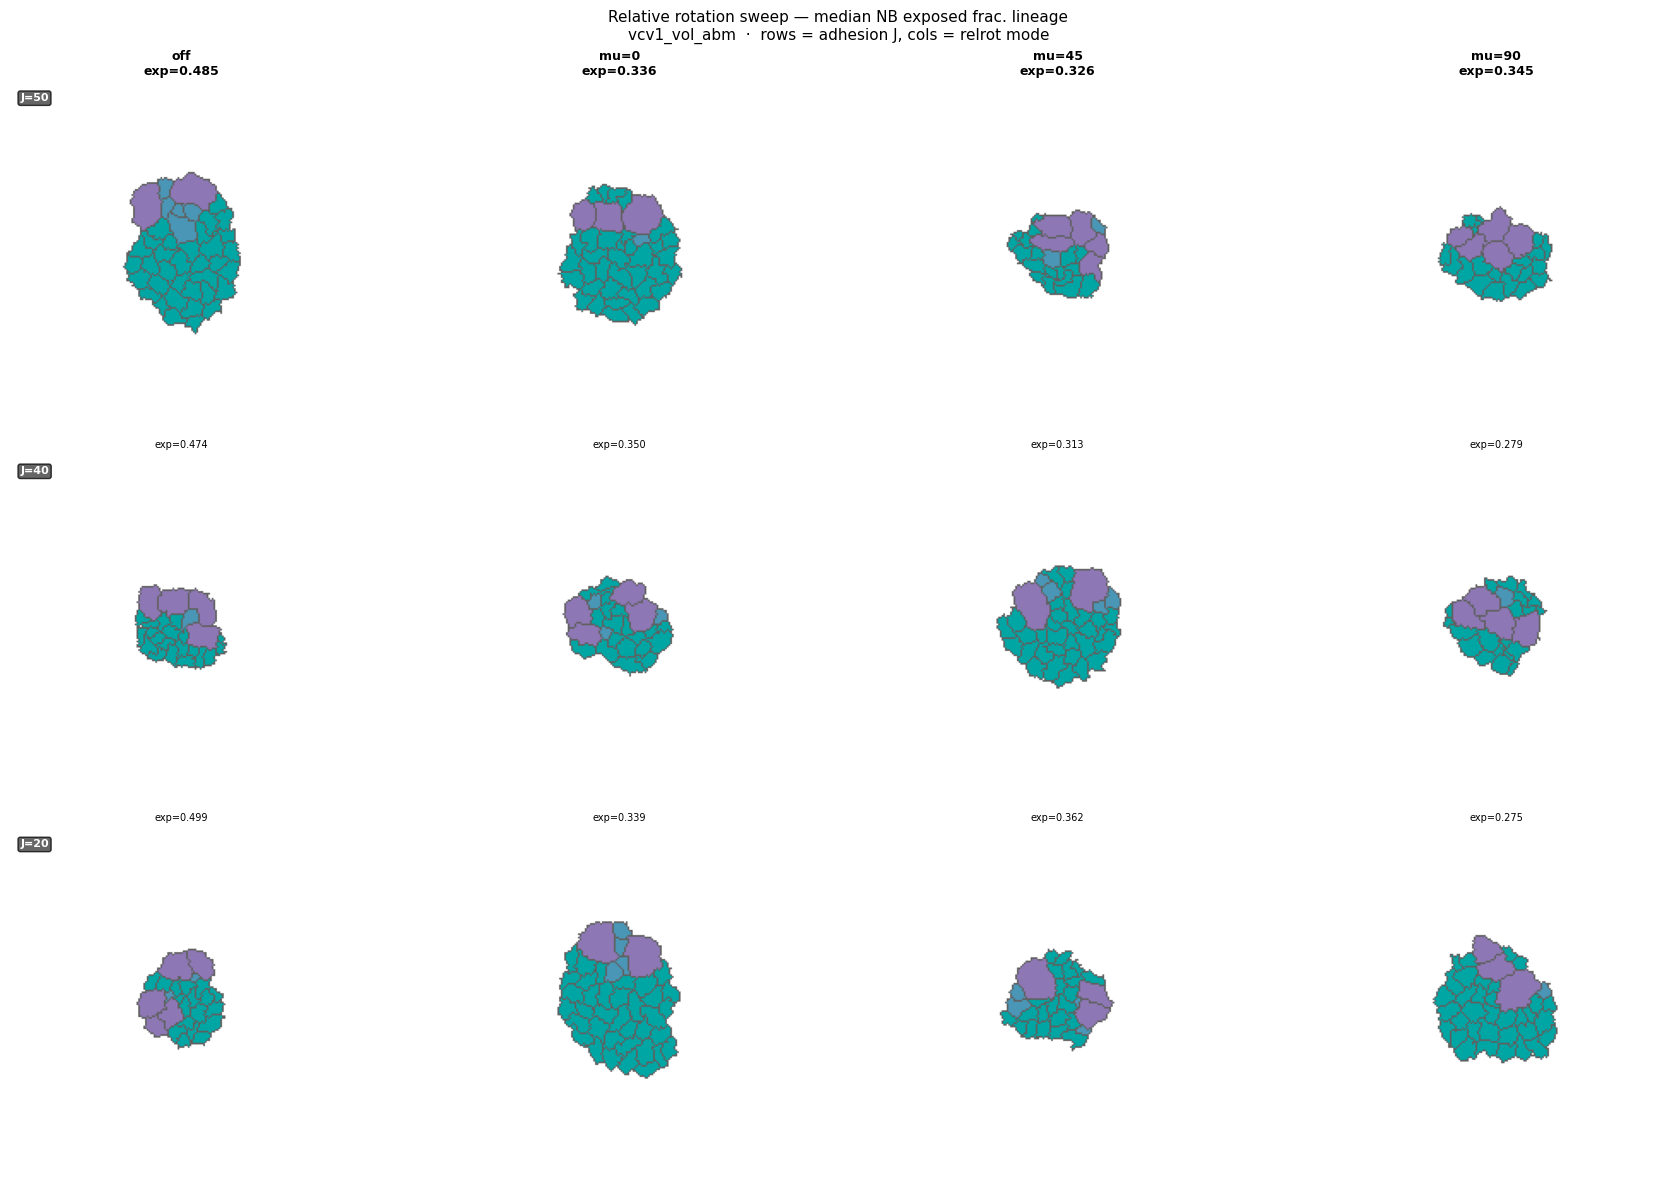

In [12]:
_SIM_ID = 'vcv1_vol_abm'

fig, axes = plt.subplots(
    len(ADH_ORDER), len(RELROT_ORDER),
    figsize=(4.5 * len(RELROT_ORDER), 4 * len(ADH_ORDER)),
    squeeze=False,
)

for ri, adh in enumerate(ADH_ORDER):
    for ci, rl in enumerate(RELROT_ORDER):
        ax      = axes[ri, ci]
        cond    = _cond_name(adh, rl)
        med_val = _render_median_run(cond, _SIM_ID, exp_df, 'exposed_frac', ax)

        title_lines = []
        if ri == 0:
            title_lines.append(rl)
        if not np.isnan(med_val):
            title_lines.append(f'exp={med_val:.3f}')
        ax.set_title('\n'.join(title_lines),
                     fontsize=9 if ri == 0 else 7,
                     fontweight='bold' if ri == 0 else 'normal')

        if ci == 0:
            ax.text(0.03, 0.97, f'J={adh}', transform=ax.transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left',
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.75))

fig.suptitle(
    f'Relative rotation sweep — median NB exposed frac. lineage\n'
    f'{_SIM_ID}  ·  rows = adhesion J, cols = relrot mode',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'relrot_sweep_example_lineages.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Section 4 — NB Connectivity Heatmap

Rows = adhesion level (50 / 40 / 20), columns = relative-rotation mode (off / mu=0 / mu=45 / mu=90).
Cell value = fraction of 50 runs where all NBs form one connected component.

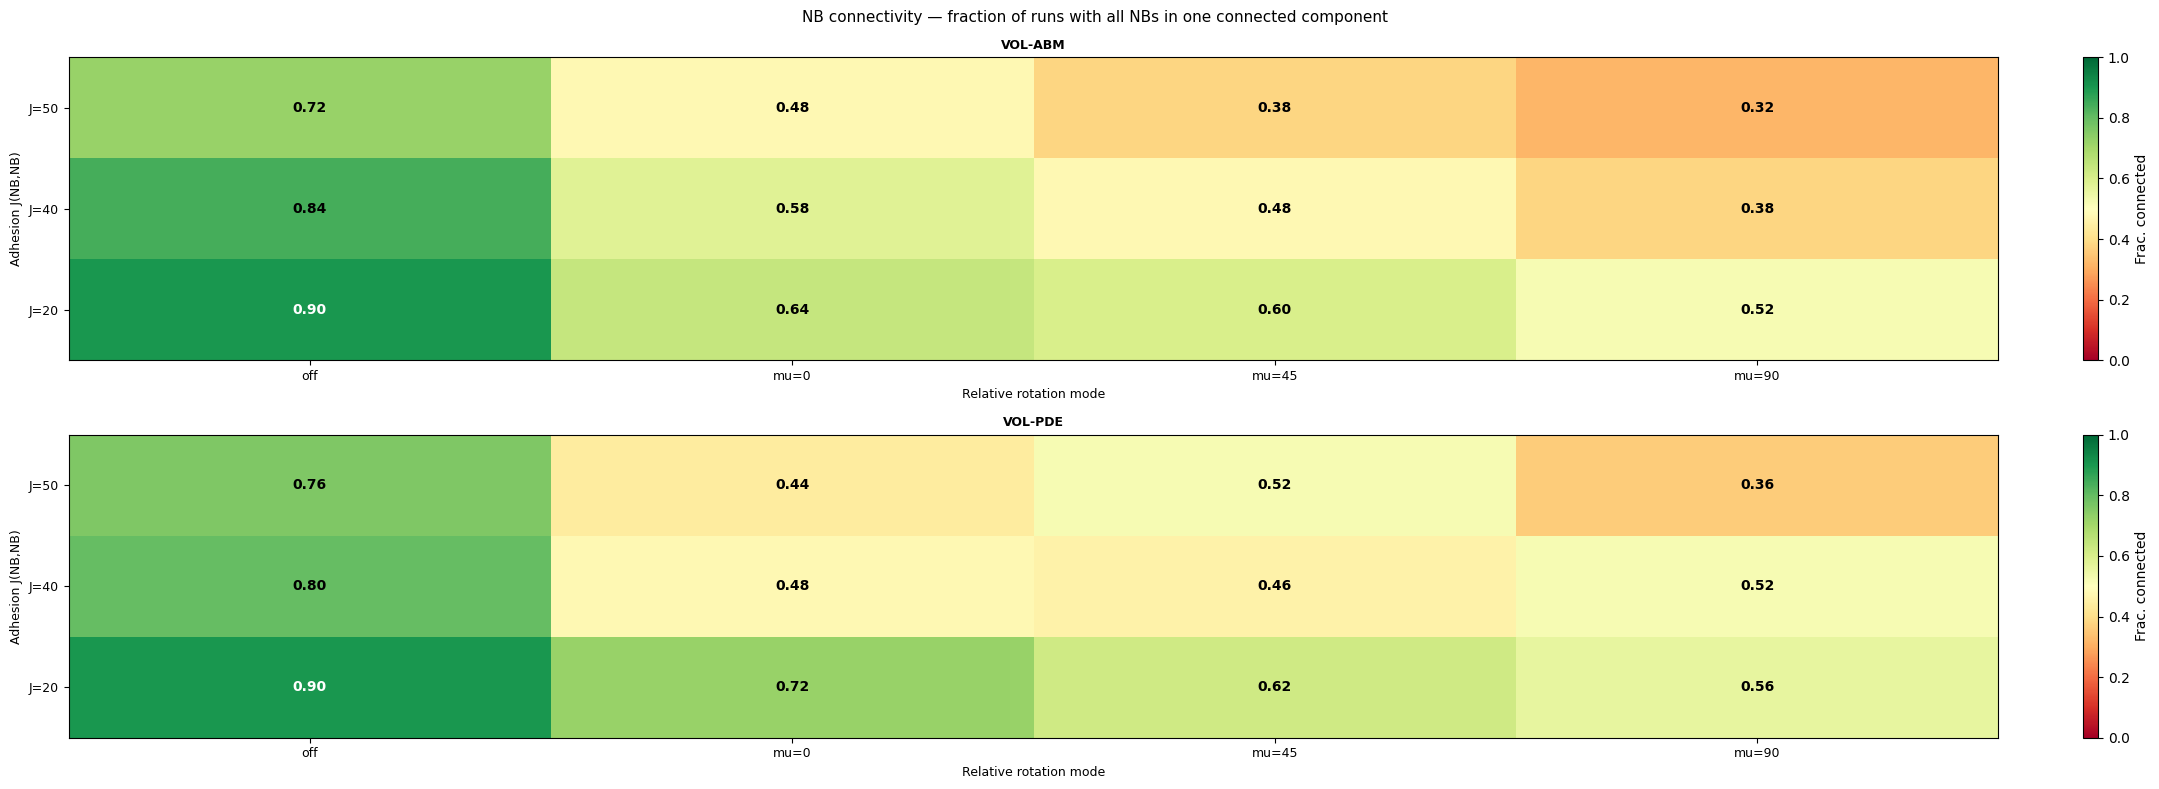

In [13]:
fig, axes = plt.subplots(
    len(REG_DYN_ORDER), 1,
    figsize=(5.5 * len(RELROT_ORDER), 4 * len(REG_DYN_ORDER)),
    squeeze=False,
)

for ri, reg_dyn in enumerate(REG_DYN_ORDER):
    ax = axes[ri, 0]
    sub = all_df[all_df['regulatory_dynamic'] == reg_dyn]

    mat = np.full((len(ADH_ORDER), len(RELROT_ORDER)), np.nan)
    for ai, adh in enumerate(ADH_ORDER):
        for rli, rl in enumerate(RELROT_ORDER):
            vals = sub[
                (sub['adhesion'] == adh) & (sub['relrot_label'] == rl)
            ]['nb_connected'].dropna()
            if not vals.empty:
                mat[ai, rli] = float(vals.mean())

    im = ax.imshow(mat, vmin=0, vmax=1, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(len(RELROT_ORDER)))
    ax.set_xticklabels(RELROT_ORDER, fontsize=9)
    ax.set_yticks(range(len(ADH_ORDER)))
    ax.set_yticklabels([f'J={a}' for a in ADH_ORDER], fontsize=9)
    ax.set_xlabel('Relative rotation mode', fontsize=9)
    ax.set_ylabel('Adhesion J(NB,NB)', fontsize=9)

    for ai in range(len(ADH_ORDER)):
        for rli in range(len(RELROT_ORDER)):
            v = mat[ai, rli]
            if not np.isnan(v):
                txt_color = 'black' if 0.15 < v < 0.85 else 'white'
                ax.text(rli, ai, f'{v:.2f}', ha='center', va='center',
                        fontsize=10, fontweight='bold', color=txt_color)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Frac. connected')
    ax.set_title(f'{reg_dyn}', fontsize=9, fontweight='bold')

fig.suptitle(
    'NB connectivity — fraction of runs with all NBs in one connected component',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'connectivity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

### Section 4b — Connectivity Heatmap: Example Lineages

3×4 grid (rows = adhesion J, cols = relative rotation mode).
Each cell shows the run at median `nb_cohesion_frac` for that condition, VOL-ABM.

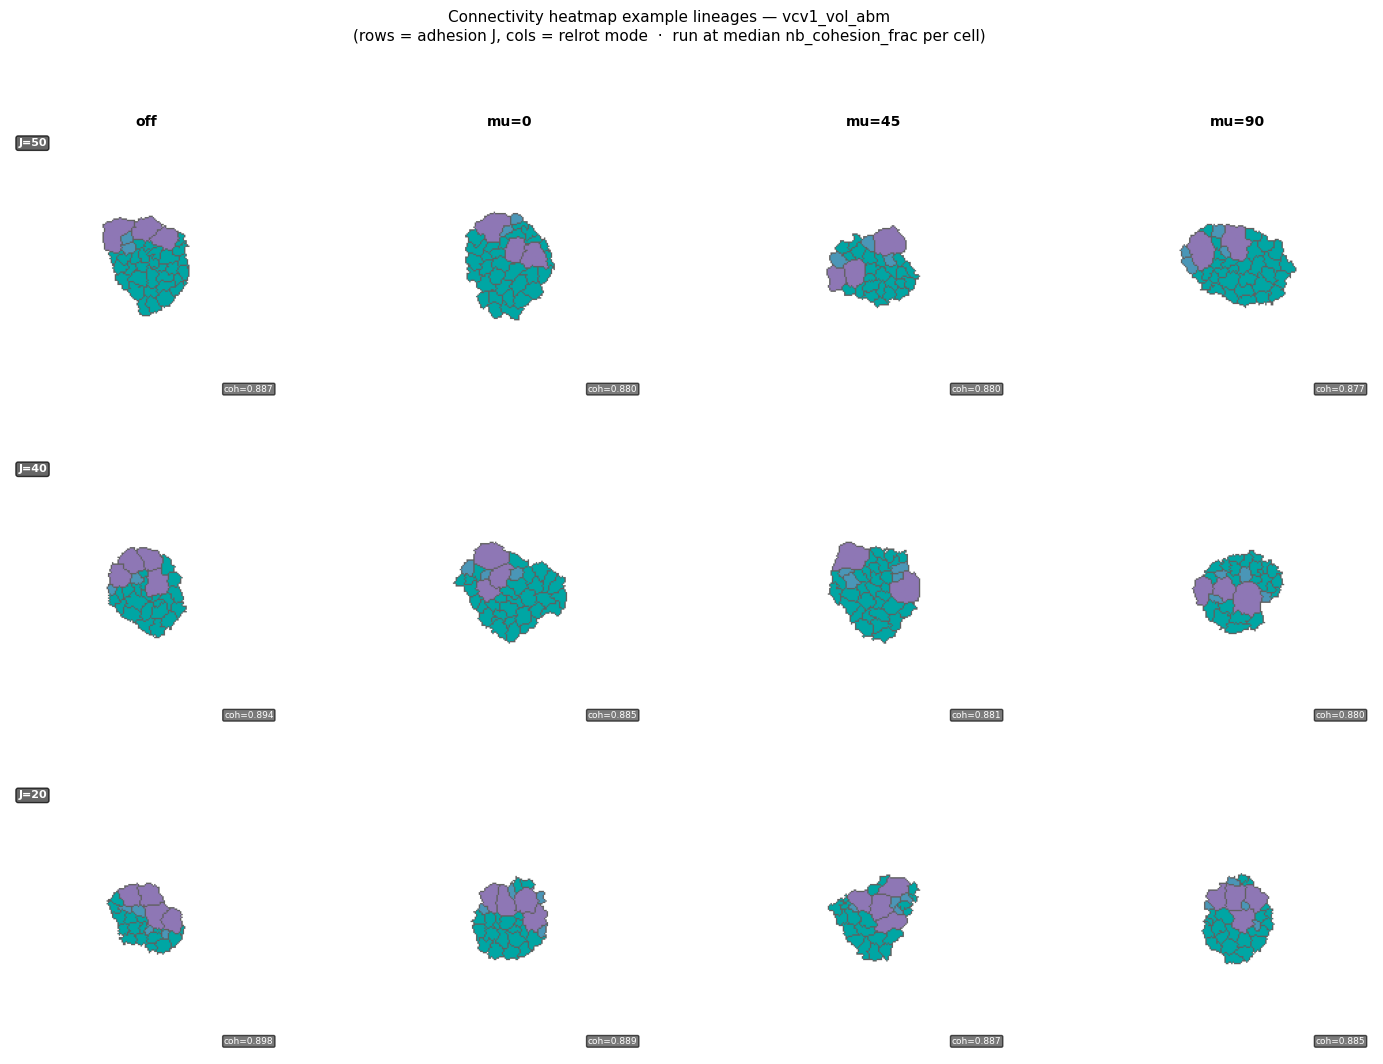

In [14]:
_SIM_ID = 'vcv1_vol_abm'

fig, axes = plt.subplots(
    len(ADH_ORDER), len(RELROT_ORDER),
    figsize=(4.5 * len(RELROT_ORDER), 4 * len(ADH_ORDER)),
    squeeze=False,
)

for ri, adh in enumerate(ADH_ORDER):
    for ci, rl in enumerate(RELROT_ORDER):
        ax      = axes[ri, ci]
        cond    = _cond_name(adh, rl)
        med_val = _render_median_run(cond, _SIM_ID, coh_df, 'nb_cohesion_frac', ax)

        if ri == 0:
            ax.set_title(rl, fontsize=10, fontweight='bold', pad=3)

        if not np.isnan(med_val):
            ax.text(0.97, 0.03, f'coh={med_val:.3f}', transform=ax.transAxes,
                    fontsize=6.5, va='bottom', ha='right', color='white',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='#333333', alpha=0.65))

        if ci == 0:
            ax.text(0.03, 0.97, f'J={adh}', transform=ax.transAxes,
                    fontsize=8, fontweight='bold', va='top', ha='left',
                    color='white',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='#333333', alpha=0.75))

fig.suptitle(
    f'Connectivity heatmap example lineages — {_SIM_ID}\n'
    '(rows = adhesion J, cols = relrot mode  ·  run at median nb_cohesion_frac per cell)',
    fontsize=11,
)
plt.savefig(FIGURES_DIR / 'connectivity_heatmap_example_lineages.png',
            dpi=120, bbox_inches='tight')
plt.show()

---
## Section 5 — Example Lineages

One representative end-state image per adhesion level at relrot=off, VOL-ABM.
Each image is the run closest to the median `nb_cohesion_frac` for that condition,
giving visual intuition for J=50 / J=40 / J=20.

In [15]:
import npa.sim_viz as _sim_viz_mod

NB_COLOR   = _sim_viz_mod.NB_COLOR
POP2_COLOR = _sim_viz_mod.POP2_COLOR
POP3_COLOR = _sim_viz_mod.POP3_COLOR


def draw_example_lineage(condition, sim_id, ax, title=''):
    """Render the run closest to median nb_cohesion_frac."""
    sub = coh_df[(coh_df['condition'] == condition) & (coh_df['sim_id'] == sim_id)]
    if sub.empty:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        return
    med = sub['nb_cohesion_frac'].median()
    best_idx = (sub['nb_cohesion_frac'] - med).abs().idxmin()
    run_id_str = str(int(sub.loc[best_idx, 'run_id'])).zfill(4)

    match = run_idx[
        (run_idx['condition'] == condition) &
        (run_idx['sim_id']    == sim_id) &
        (run_idx['run_id']    == run_id_str)
    ]
    if match.empty:
        ax.text(0.5, 0.5, f'run {run_id_str} not in index',
                ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        return

    r = match.iloc[0]
    geo_raw, lmap = load_raw_snapshot_full(
        REPO_ROOT / r['cells_path'],
        REPO_ROOT / r['locs_path'],
    )
    render_raw(geo_raw, label_map=lmap, ax=ax, title=title)
    ax.axis('off')

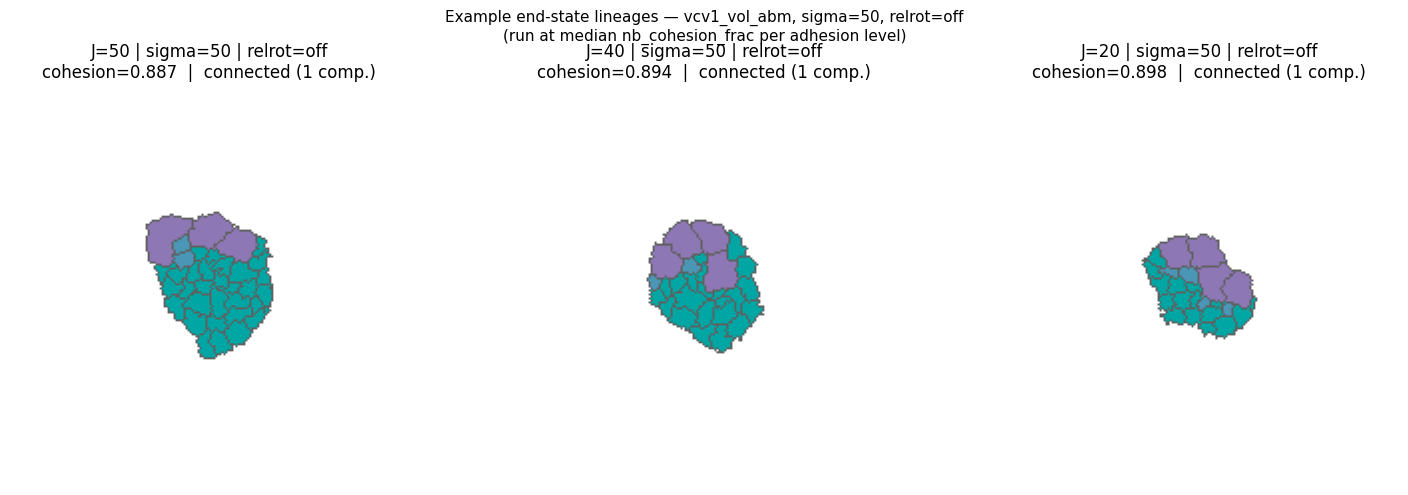

In [16]:
_SIM_ID = 'vcv1_vol_abm'
_SIGMA  = 50

fig, axes = plt.subplots(1, len(ADH_ORDER), figsize=(5 * len(ADH_ORDER), 5))

for i, adh in enumerate(ADH_ORDER):
    cond = f'mudmut_adh{adh}_divMean0Stdev{_SIGMA}'

    # Find median-cohesion run
    sub_coh = coh_df[(coh_df['condition'] == cond) & (coh_df['sim_id'] == _SIM_ID)]
    if not sub_coh.empty:
        med_coh  = sub_coh['nb_cohesion_frac'].median()
        best_run = int(sub_coh.loc[
            (sub_coh['nb_cohesion_frac'] - med_coh).abs().idxmin(), 'run_id'
        ])
    else:
        med_coh, best_run = float('nan'), None

    # Look up connectivity for that same run
    if best_run is not None:
        conn_row = conn_df[
            (conn_df['condition'] == cond) &
            (conn_df['sim_id']    == _SIM_ID) &
            (conn_df['run_id']    == best_run)
        ]
        if not conn_row.empty:
            n_comp    = int(conn_row['nb_n_components'].iloc[0])
            connected = bool(conn_row['nb_connected'].iloc[0])
            conn_str  = f'connected ({n_comp} comp.)' if connected else f'disconnected ({n_comp} comp.)'
        else:
            conn_str = 'connectivity N/A'
    else:
        conn_str = 'no data'

    title = (
        f'J={adh} | sigma={_SIGMA} | relrot=off\n'
        f'cohesion={med_coh:.3f}  |  {conn_str}'
    )
    draw_example_lineage(condition=cond, sim_id=_SIM_ID, ax=axes[i], title=title)

fig.suptitle(
    f'Example end-state lineages — {_SIM_ID}, sigma={_SIGMA}, relrot=off\n'
    '(run at median nb_cohesion_frac per adhesion level)',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'example_lineages_adhesion_levels.png', dpi=120, bbox_inches='tight')
plt.show()